# Classification of Stress from Physiological data

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.figure as figure
import pandas as pd
from datetime import datetime
import joblib

from IPython.display import display

from imblearn.over_sampling import ADASYN
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, balanced_accuracy_score, f1_score
from sklearn.pipeline import Pipeline

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.feature_selection import RFECV

from make_classification import avg_res, make_nclassif_random_splits, make_nclassif_kfold

STD_BY_SUBJ = True
std_suffix = ".stdsubj" if STD_BY_SUBJ else ".stdtask"

BASE_PATH = "../../experiment-data"
LABELS_SEPARATOR = ","
LABELS_FILENAME = f"{BASE_PATH}/labels.csv"
FEATURES_SEPARATOR = ";"
FEATURES_DIRECTORY = f"{BASE_PATH}/extracted-features"
FEATURES_FILENAME = f"{FEATURES_DIRECTORY}/all_features{std_suffix}.csv"
RESULTS_SEPARATOR = ","
RESULTS_DIRECTORY = f"{BASE_PATH}/results/InterTasks"
BIN_LABELS = ["NoStress", "Stress"]
TER_LABELS = ["Relaxed", "Stress", "RealStress"]
QAD_LABELS = ["Relaxed", "Stress", "RealStress", "Amused"]
DEBUG = True
FLOAT_TYPE = np.float64

STRESS_TASKS = ["Baseline", "AmusementClip", "StressClip"]
FRUSTRATION_TASKS = ["EmoReset", "FormL", "FormM"]

In [2]:
def make_results_filename(classification: str, feature_selection: str | None, state_int: int) -> str:
    now = datetime.now()
    timestamp = now.strftime("%Y%m%d-%H%M%S")
    feature_selection = feature_selection if feature_selection is not None else "None"
    return f"{RESULTS_DIRECTORY}/{timestamp}_{classification}_{feature_selection}f.{state_int}"

def show_label_stats(labels: list[str], y: pd.Series):
    df = pd.DataFrame(
        {
            "labels": labels,
            "counts": y.value_counts().to_list(),
            "percentage": (y.value_counts(normalize=True) * 100).to_list(),
        },
    )
    display(df.set_index("labels"))

def output(results: pd.DataFrame, conf_matrices: dict[str, np.ndarray], meta: dict):
    classification = meta['classification']
    feature_selector = meta['feature_selector']
    state_int = meta['state_int']
    labels = meta['classes']
    averages = avg_res(results)
    if meta['save_results']:
        res_file = make_results_filename(classification, feature_selector, state_int) + ".csv"
        avg_file = make_results_filename(classification, feature_selector, state_int) + ".avg.csv"
        print(f"Saving results to {res_file}, {avg_file}")
        results.to_csv(res_file, sep=RESULTS_SEPARATOR, index=True)
        averages.to_csv(avg_file, sep=RESULTS_SEPARATOR, index=True)

    # Show results
    if meta['show_averages']:
        display(averages)
    if meta['show_confusion_matrices']:
        cm_file = make_results_filename(classification, feature_selector, state_int) + ".CM.png"
        ncms = len(conf_matrices)
        pairs = [(name, cm) for name, cm in conf_matrices.items()]
        nrows = (ncms // 2) + (ncms % 2)
        fig, axes = plt.subplots(nrows, 2, figsize=(8, nrows*4))
        for (name, cm), ax in zip(pairs, axes.ravel()):
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
            disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
            ax.set_title(name)
        fig.suptitle("Confusion Matrices")
        plt.tight_layout()
        if meta["save_results"]:
            print(f"Saving confusion matrix to {cm_file}")
            plt.savefig(cm_file, dpi=300, format="png")
        plt.show()


def save_models(classifiers: dict[str, Pipeline], meta: dict):
    classification = meta["classification"]
    for name, cls in classifiers.items():
        now = datetime.now()
        timestamp = now.strftime("%Y%m%d-%H%M%S")
        filename = (
            f"{RESULTS_DIRECTORY}/{timestamp}_{classification}_{name}_{meta['feature_selector']}f.joblib"
        )
        joblib.dump(cls, filename)
        print(f"Model {name} saved to {filename}")

def show_results(log_prefix: str, results: pd.DataFrame, meta: dict, save=False):
    feature_selector = meta["feature_selector"]
    state_int = meta["state_int"]
    display(results)
    if save:
        res_file = make_results_filename(log_prefix, feature_selector, state_int) + ".csv"
        print(f"Saving results to {res_file}")
        results.to_csv(res_file, sep=RESULTS_SEPARATOR, index=True)


def show_confusion_matrices(log_prefix: str, conf_matrices: dict[str, np.ndarray], meta: dict, save=False):
    feature_selector = meta["feature_selector"]
    state_int = meta["state_int"]
    labels = meta["classes"]
    cm_file = make_results_filename(log_prefix, feature_selector, state_int) + ".CM.png"
    ncms = len(conf_matrices)
    pairs = [(name, cm) for name, cm in conf_matrices.items()]
    nrows = (ncms // 2) + (ncms % 2)
    fig, axes = plt.subplots(nrows, 2, figsize=(8, nrows * 4))
    for (name, cm), ax in zip(pairs, axes.ravel()):
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
        ax.set_title(name)
    fig.suptitle("Confusion Matrices")
    plt.tight_layout()
    if save:
        print(f"Saving confusion matrix to {cm_file}")
        plt.savefig(cm_file, dpi=300, format="png")
    plt.show()

#### Import labels and prepare dataset

Manually engineered features

In [3]:
X = pd.read_csv(FEATURES_FILENAME, sep=FEATURES_SEPARATOR, header=0, index_col=0).dropna()
for col in X.columns:
    X[col] = X[col].astype(FLOAT_TYPE)
n_rows, n_cols = X.shape
print("======================================================")
print(f"Experiment dataset contains {n_rows} samples with {n_cols} features")
# display(X)

labels = pd.read_csv(LABELS_FILENAME, sep=LABELS_SEPARATOR, header=0, index_col=0).dropna()
n_rows, n_cols = labels.shape
print("======================================================")
print(f"Experiment labels contains {n_rows} labels with {n_cols} types of classifications")
# display(labels)

# Selecting rows that actually have entries both labels and samples
idx = list(X.merge(labels, left_index=True, right_index=True).index)
labels = labels.loc[idx]
X = X.loc[idx]
n_rows, n_cols = X.shape
print("======================================================")
print(f"Experiment classification dataset contains {n_rows} samples with {n_cols} features")

stress_tasks_mask = [task.split("-")[1] in STRESS_TASKS for task in X.index]
stress_X = X[stress_tasks_mask]
stress_bin_y = labels['binary-stress'][stress_tasks_mask]
stress_ter_y = labels['affect3-class'][stress_tasks_mask]
stress_qad_y = labels['affect4-class'][stress_tasks_mask]

frust_tasks_mask = [task.split("-")[1] in FRUSTRATION_TASKS for task in X.index]
frust_X = X[frust_tasks_mask]
frust_bin_y = labels["binary-stress"][frust_tasks_mask]
frust_ter_y = labels["affect3-class"][frust_tasks_mask]
frust_qad_y = labels["affect4-class"][frust_tasks_mask]

def subject_to_group(subjID):
    return int(subjID) - 1

stress_subject_list: list[int] = []
frust_subject_list: list[int] = []
for sample_name in labels["binary-stress"].index:
    subject_id, task = sample_name.split("-")
    if task in STRESS_TASKS:
        stress_subject_list.append(subject_to_group(subject_id))
    else:
        frust_subject_list.append(subject_to_group(subject_id))

n_rows, n_cols = stress_X.shape
print("\n======================================================")
print(f"Stress (Video) tasks dataset contains {n_rows} samples with {n_cols} features")
print(f"Stress tasks subjects list is {len(stress_subject_list)} members long, having {len(set(stress_subject_list))} distinct subjects.")
n_rows, n_cols = frust_X.shape
print("======================================================")
print(f"Frustration (Calculator) tasks dataset contains {n_rows} samples with {n_cols} features")
print(
    f"Frustration tasks subjects list is {len(frust_subject_list)} members long, having {len(set(frust_subject_list))} distinct subjects."
)

Experiment dataset contains 147 samples with 70 features
Experiment labels contains 126 labels with 3 types of classifications
Experiment classification dataset contains 126 samples with 70 features

Stress (Video) tasks dataset contains 63 samples with 70 features
Stress tasks subjects list is 63 members long, having 21 distinct subjects.
Frustration (Calculator) tasks dataset contains 63 samples with 70 features
Frustration tasks subjects list is 63 members long, having 21 distinct subjects.


# Training, Statistical features

Several models are tested: Random Forests, K nearets neighbors, SVM, and Multi Layer Perceptron. All models are fitted 10 times on random splits and 5-fold, and the average scores of the repetitions are reported.

### Parameter and models configuration

In [4]:
training_tasks = "calc"  # Literal["video" | "calc"]
params = {
    "training_tasks": training_tasks,
    "testing_tasks": "calc" if training_tasks == "video" else "video",
    "state_int": 21,
    "feature_selector": "RFE",  # None, 'PCA', 'L1', or 'RFE' (ordered by speed)
    "test_size": 0.2,  # Paper value: 0.2
    "n_splits": 10,  # Paper value: 10
    "data_augmentation": True,
    "show_averages": True,
    "show_confusion_matrices": True,
    "save_confusion_matrices": True,
    "save_models": True,
    "save_results": True,
    "verbose": False,
}

validations = {
    'holdout': True,
    'kfold': True
}

list_classif = [
    RandomForestClassifier(bootstrap=True, max_depth=40, max_features="log2", min_samples_leaf=1, min_samples_split=2, n_estimators=450, random_state=params["state_int"]),
    KNeighborsClassifier(n_neighbors=2, p=1, weights="distance"),
    SVC(C=1000, gamma="auto", kernel="rbf", random_state=params["state_int"], probability=True),
    MLPClassifier(activation="tanh", alpha=0.008, hidden_layer_sizes=(100,), learning_rate_init=0.005, max_iter=10000, random_state=params["state_int"]),
]

if params["training_tasks"] == "video":
    trainset_name = "Stress Tasks"
    trainset_x = stress_X.copy()
    trainset_bin_y = stress_bin_y.copy()
    trainset_ter_y = stress_ter_y.copy()
    trainset_qad_y = stress_qad_y.copy()
    trainsubject_list = stress_subject_list.copy()
    testset_name = "Frustration Tasks"
    testset_x = frust_X.copy()
    testset_bin_y = frust_bin_y.copy()
    testset_ter_y = frust_ter_y.copy()
    testset_qad_y = frust_qad_y.copy()
    testsubject_list = frust_subject_list.copy()
else:
    trainset_name = "Frustration Tasks"
    trainset_x = frust_X.copy()
    trainset_bin_y = frust_bin_y.copy()
    trainset_ter_y = frust_ter_y.copy()
    trainset_qad_y = frust_qad_y.copy()
    trainsubject_list = frust_subject_list.copy()
    testset_name = "Stress Tasks"
    testset_x = stress_X.copy()
    testset_bin_y = stress_bin_y.copy()
    testset_ter_y = stress_ter_y.copy()
    testset_qad_y = stress_qad_y.copy()
    testsubject_list = stress_subject_list.copy()

### Binary classification

In [5]:
params['classification'] = 'binary'
params['classes'] = BIN_LABELS
show_label_stats(params['classes'], trainset_bin_y)

if params["data_augmentation"]:
    ada = ADASYN(random_state=params["state_int"], sampling_strategy={0:60, 1:60})
    x_in, y_in = ada.fit_resample(trainset_x, trainset_bin_y)
    print("Resampled dataset")
    show_label_stats(params["classes"], y_in)
else:
    x_in = trainset_x.copy()
    y_in = trainset_bin_y.copy()

    # Visualise class distribution
    plt.figure(figsize=(12, 6))

    bin_stats = pd.DataFrame(
        {
            "Value": y_in.values,
            "Subject": [idx.split("-")[0] for idx in y_in.index],
            "Task": [idx.split("-")[1] for idx in y_in.index],
        },
        index=y_in.index,
    )
    for cls_id, cls_name in enumerate(params["classes"]):
        bin_stats[cls_name] = [value == cls_id for value in y_in]

    tasks = sorted(bin_stats['Task'].unique())
    x_positions = np.arange(len(tasks))
    width = 0.35

    # Plot bars and scatter points for each class
    for i, class_name in enumerate(params["classes"]):
        counts = bin_stats.groupby('Task')[class_name].sum()
        bars = plt.bar(x_positions + (i-0.5)*width, [counts[task] for task in tasks], width,
                        label=class_name, alpha=0.7)

    plt.xlabel('Task')
    plt.ylabel('Count')
    plt.title('Number of instances per class by Task')
    plt.xticks(x_positions, tasks, rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nInstances count per task:")
    display(bin_stats.groupby('Task')[params["classes"]].sum())

,counts,percentage
labels,,
NoStress,36,57.142857
Stress,27,42.857143


Resampled dataset


,counts,percentage
labels,,
NoStress,63,50.4
Stress,62,49.6


Split  1/10
Split  2/10
Split  3/10
Split  4/10
Split  5/10
Split  6/10
Split  7/10
Split  8/10
Split  9/10
Split 10/10
Saving results to ../../experiment-data/results/InterTasks/20251020-202420_binary_RFEf.21.csv, ../../experiment-data/results/InterTasks/20251020-202420_binary_RFEf.21.avg.csv


,f1-score,accuracy,time
classifier,,,
KNeighborsClassifier,0.882047,0.884450,5.062031
MLPClassifier_HLs(100),0.899823,0.903178,5.009799
RandomForestClassifier,0.883592,0.884557,5.373789
SVC,0.892119,0.893082,5.175258


Saving confusion matrix to ../../experiment-data/results/InterTasks/20251020-202420_binary_RFEf.21.CM.png


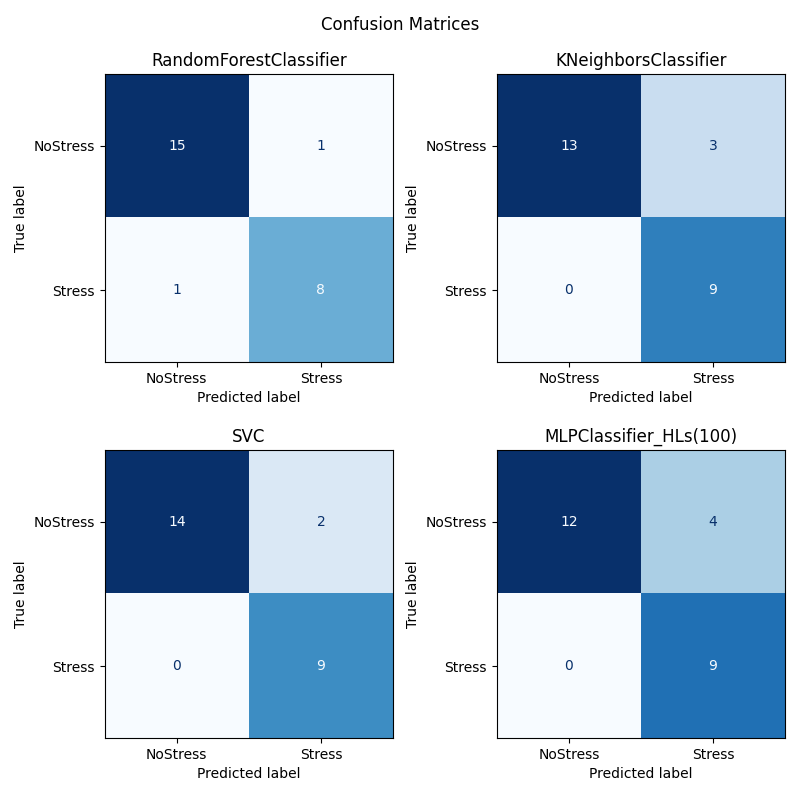

Model RandomForestClassifier saved to ../../experiment-data/results/InterTasks/20251020-202421_binary_RandomForestClassifier_RFEf.joblib
Model KNeighborsClassifier saved to ../../experiment-data/results/InterTasks/20251020-202421_binary_KNeighborsClassifier_RFEf.joblib
Model SVC saved to ../../experiment-data/results/InterTasks/20251020-202421_binary_SVC_RFEf.joblib
Model MLPClassifier_HLs(100) saved to ../../experiment-data/results/InterTasks/20251020-202421_binary_MLPClassifier_HLs(100)_RFEf.joblib
Standard Deviations 10 holdouts:


,f1-score,accuracy,time
classifier,,,
KNeighborsClassifier,0.069894,0.066748,0.582641
MLPClassifier_HLs(100),0.054288,0.053941,0.642395
RandomForestClassifier,0.048478,0.051693,0.612934
SVC,0.065216,0.065383,0.438762


In [6]:
# 10 random splits holdout
if validations['holdout']:
    res, conf, models, probs_dict = make_nclassif_random_splits(
        x_in,
        y_in,
        n_splits=params["n_splits"],
        feature_selector=params["feature_selector"],
        list_classifiers=list_classif,
        random_seed=params["state_int"],
        test_size=params["test_size"],
        verbose=params["verbose"],
        useStratification=False,
    )
    output(res, conf, params)
    if params["save_models"]:
        save_models(models, params)

    print(f"Standard Deviations {params['n_splits']} holdouts:")
    display(res.groupby(["classifier"]).std()[["f1-score", "accuracy", "time"]])

    if not params["data_augmentation"]:
        for model_name, probs_df in probs_dict.items():
            agg_cols = {}
            for cls_idx, cls_name in enumerate(params["classes"]):
                agg_cols[cls_idx] = cls_name
            probs_df["Subject"] = [idx.split("_")[0] for idx in probs_df.index]
            probs_df["Task"] = [idx.split("_")[1] for idx in probs_df.index]
            probs_dict[model_name] = probs_df.rename(columns=agg_cols).reset_index(drop=True)

In [7]:
if not params["data_augmentation"]:
    for model_name, probs_df in probs_dict.items():
        print(f"\n{model_name}")
        plt.figure(figsize=(12, 6))

        tasks = sorted(probs_df['Task'].unique())
        x_positions = np.arange(len(tasks))
        width = 0.35

        # Plot bars and scatter points for each class
        for i, class_name in enumerate(params["classes"]):
            means = probs_df.groupby('Task')[class_name].mean()
            bars = plt.bar(x_positions + (i-0.5)*width, [means[task] for task in tasks], width,
                        label=class_name, alpha=0.7)

            # Add scatter points
            for j, task in enumerate(tasks):
                task_data = probs_df[probs_df['Task'] == task][class_name]
                x_jitter = np.random.normal(0, 0.04, size=len(task_data))
                plt.scatter(np.repeat(x_positions[j] + (i-0.5)*width, len(task_data)) + x_jitter,
                        task_data, color='black', alpha=0.1, s=30)

        plt.xlabel('Task')
        plt.ylabel('Probability')
        plt.title(f'Class Probabilities by Task - {model_name}')
        plt.xticks(x_positions, tasks, rotation=45)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.ylim(-0.05, 1.05)
        plt.tight_layout()
        plt.show()

        # Summary
        agg_cols = {}
        for cls_name in params["classes"]:
            agg_cols[cls_name] = ["mean", "count", "std"]
        probs_stats = probs_df.groupby("Task").agg(agg_cols)
        display(probs_stats)

Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
Saving results to ../../experiment-data/results/InterTasks/20251020-202626_binary_RFEf.21.csv, ../../experiment-data/results/InterTasks/20251020-202626_binary_RFEf.21.avg.csv


,f1-score,accuracy,time
classifier,,,
KNeighborsClassifier,0.870972,0.872564,5.320391
MLPClassifier_HLs(100),0.887974,0.891538,5.335525
RandomForestClassifier,0.896161,0.896923,4.729686
SVC,0.863000,0.869103,5.461403


Saving confusion matrix to ../../experiment-data/results/InterTasks/20251020-202626_binary_RFEf.21.CM.png


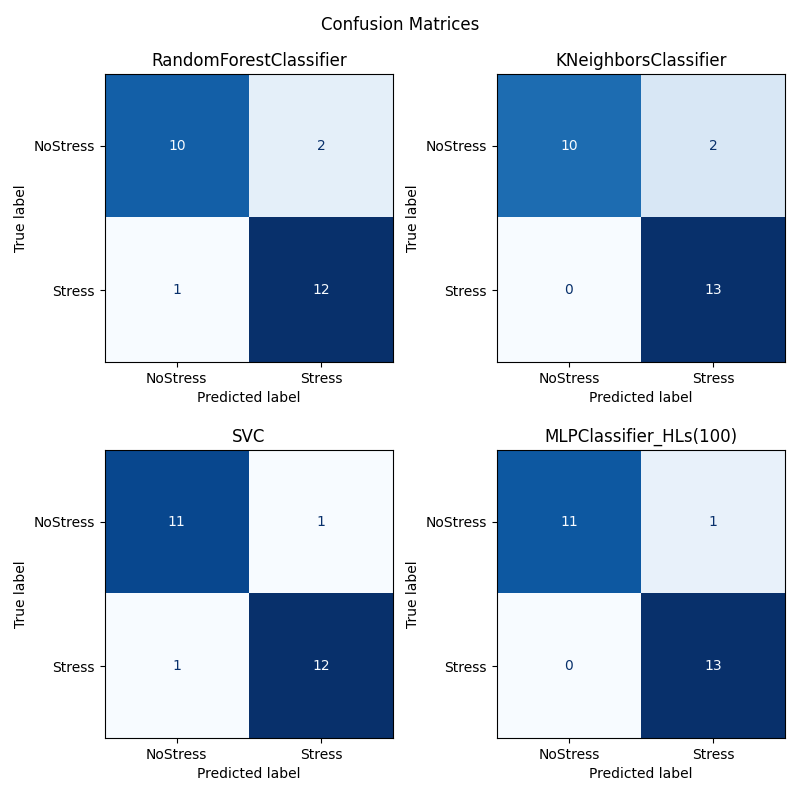

Model RandomForestClassifier saved to ../../experiment-data/results/InterTasks/20251020-202627_binary_RandomForestClassifier_RFEf.joblib
Model KNeighborsClassifier saved to ../../experiment-data/results/InterTasks/20251020-202627_binary_KNeighborsClassifier_RFEf.joblib
Model SVC saved to ../../experiment-data/results/InterTasks/20251020-202627_binary_SVC_RFEf.joblib
Model MLPClassifier_HLs(100) saved to ../../experiment-data/results/InterTasks/20251020-202627_binary_MLPClassifier_HLs(100)_RFEf.joblib
Standard Deviations 5-folds cross-validation:


,f1-score,accuracy,time
classifier,,,
KNeighborsClassifier,0.044306,0.042933,0.276257
MLPClassifier_HLs(100),0.043773,0.044921,0.388433
RandomForestClassifier,0.035692,0.036212,0.389427
SVC,0.062675,0.061799,0.535807


In [8]:
# 5-fold cross-validation
if validations['kfold']:
    res, conf, models, probs_dict = make_nclassif_kfold(
        x_in,
        y_in,
        feature_selector=params["feature_selector"],
        list_classifiers=list_classif,
        random_seed=params["state_int"],
        verbose=params["verbose"],
        stratified=False,
    )
    output(res, conf, params)
    if params["save_models"]:
        save_models(models, params)

    print("Standard Deviations 5-folds cross-validation:")
    display(res.groupby(["classifier"]).std()[["f1-score", "accuracy", "time"]])

    if not params["data_augmentation"]:
        for model_name, probs_df in probs_dict.items():
            agg_cols = {}
            for cls_idx, cls_name in enumerate(params["classes"]):
                agg_cols[cls_idx] = cls_name
            probs_df["Subject"] = [idx.split("_")[0] for idx in probs_df.index]
            probs_df["Task"] = [idx.split("_")[1] for idx in probs_df.index]
            probs_dict[model_name] = probs_df.rename(columns=agg_cols).reset_index(drop=True)

In [9]:
if not params["data_augmentation"]:
    for model_name, probs_df in probs_dict.items():
        print(f"\n{model_name}")
        plt.figure(figsize=(12, 6))

        tasks = sorted(probs_df['Task'].unique())
        x_positions = np.arange(len(tasks))
        width = 0.35

        # Plot bars and scatter points for each class
        for i, class_name in enumerate(params["classes"]):
            means = probs_df.groupby('Task')[class_name].mean()
            bars = plt.bar(x_positions + (i-0.5)*width, [means[task] for task in tasks], width,
                        label=class_name, alpha=0.7)

            # Add scatter points
            for j, task in enumerate(tasks):
                task_data = probs_df[probs_df['Task'] == task][class_name]
                x_jitter = np.random.normal(0, 0.04, size=len(task_data))
                plt.scatter(np.repeat(x_positions[j] + (i-0.5)*width, len(task_data)) + x_jitter,
                        task_data, color='black', alpha=0.1, s=30)

        plt.xlabel('Task')
        plt.ylabel('Probability')
        plt.title(f'Class Probabilities by Task - {model_name}')
        plt.xticks(x_positions, tasks, rotation=45)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.ylim(-0.05, 1.05)
        plt.tight_layout()
        plt.show()

        # Summary
        agg_cols = {}
        for cls_name in params["classes"]:
            agg_cols[cls_name] = ["mean", "count", "std"]
        probs_stats = probs_df.groupby("Task").agg(agg_cols)
        display(probs_stats)

### Binary test set inference (Calculator or Video tasks)



============ binary ============


Trained on CALC


,counts,percentage
labels,,
NoStress,63,50.4
Stress,62,49.6



Tested on VIDEO


,counts,percentage
labels,,
NoStress,45,71.428571
Stress,18,28.571429


,bal-accuracy,weighted-f1,macro-avg-prec,macro-avg-rec,macro-avg-f1,stress-prec,stress-rec,stress-f1
classifier,,,,,,,,
RandomForestClassifier,0.461111,0.574484,0.419643,0.461111,0.426139,0.142857,0.055556,0.080000
KNeighborsClassifier,0.433333,0.548145,0.416923,0.433333,0.422411,0.153846,0.111111,0.129032
SVC,0.472222,0.584034,0.434211,0.472222,0.433824,0.166667,0.055556,0.083333
MLPClassifier_HLs(100),0.505556,0.615160,0.508491,0.505556,0.494898,0.300000,0.166667,0.214286


Saving results to ../../experiment-data/results/InterTasks/20251020-202627_binary_calc_RFEf.21.csv
Saving confusion matrix to ../../experiment-data/results/InterTasks/20251020-202627_binary_calc_RFEf.21.CM.png


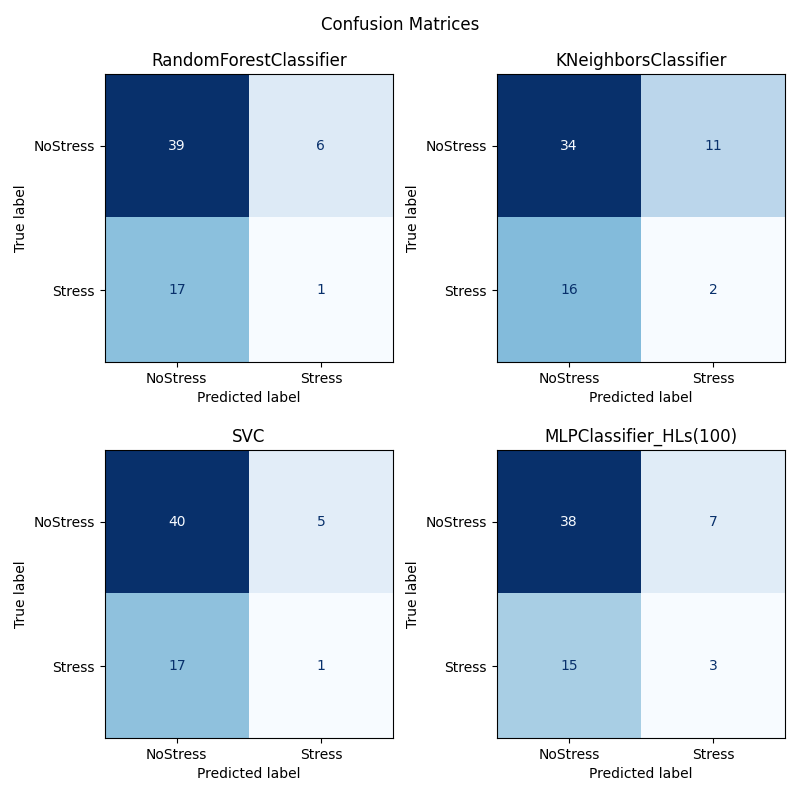

In [10]:
print(f"\n\n============ {params['classification']} ============\n\n")
print(f"Trained on {params['training_tasks'].upper()}")
show_label_stats(params["classes"], y_in)

log_type = f"{params['classification']}_{params['training_tasks']}"
df_res = pd.DataFrame(
    {
        "classifier": [],
        "bal-accuracy": [],
        "weighted-f1": [],
        "macro-avg-prec": [],
        "macro-avg-rec": [],
        "macro-avg-f1": [],
        "stress-prec": [],
        "stress-rec": [],
        "stress-f1": [],
    },
)
conf_matrices: dict[str, np.ndarray] = {}

for model_name, model in models.items():
    y_pred = model.predict(testset_x)
    cm = confusion_matrix(testset_bin_y, y_pred)
    report = classification_report(testset_bin_y, y_pred, target_names=params["classes"], output_dict=True)
    conf_matrices[model_name] = cm

    s_report = report["Stress"]
    m_report = report["macro avg"]
    new_row = {
        "classifier": model_name,
        "bal-accuracy": balanced_accuracy_score(testset_bin_y, y_pred),
        "weighted-f1": f1_score(testset_bin_y, y_pred, average="weighted"),
        "macro-avg-prec": m_report["precision"],
        "macro-avg-rec": m_report["recall"],
        "macro-avg-f1": m_report["f1-score"],
        "stress-prec": s_report["precision"],
        "stress-rec": s_report["recall"],
        "stress-f1": s_report["f1-score"],
    }
    df_res.loc[len(df_res)] = new_row

print(f"\nTested on {params['testing_tasks'].upper()}")
show_label_stats(params["classes"], testset_bin_y)

df_res.set_index("classifier", inplace=True)
show_results(log_type, df_res, params, save=params["save_results"])
if params["show_confusion_matrices"]:
    show_confusion_matrices(log_type, conf_matrices, params, save=params["save_confusion_matrices"])

### Ternary classification

In [11]:
params['classification'] = 'ternary'
params['classes'] = TER_LABELS
show_label_stats(params['classes'], trainset_ter_y)

if params["data_augmentation"]:
    ada = ADASYN(random_state=params["state_int"], sampling_strategy={0:55, 1:55, 2:55})
    x_in, y_in = ada.fit_resample(trainset_x, trainset_ter_y)
    print("Resampled dataset")
    show_label_stats(params['classes'], y_in)
else:
    x_in = trainset_x.copy()
    y_in = trainset_ter_y.copy()

,counts,percentage
labels,,
Relaxed,41,65.079365
Stress,15,23.809524
RealStress,7,11.111111


Resampled dataset


,counts,percentage
labels,,
Relaxed,55,35.031847
Stress,55,35.031847
RealStress,47,29.936306


Split  1/10
Split  2/10
Split  3/10
Split  4/10
Split  5/10
Split  6/10
Split  7/10
Split  8/10
Split  9/10
Split 10/10
Saving results to ../../experiment-data/results/InterTasks/20251020-203022_ternary_RFEf.21.csv, ../../experiment-data/results/InterTasks/20251020-203022_ternary_RFEf.21.avg.csv


,f1-score,accuracy,time
classifier,,,
KNeighborsClassifier,0.874461,0.874848,4.945945
MLPClassifier_HLs(100),0.909869,0.908182,5.054912
RandomForestClassifier,0.920022,0.919091,5.816680
SVC,0.959247,0.958182,5.085000


Saving confusion matrix to ../../experiment-data/results/InterTasks/20251020-203022_ternary_RFEf.21.CM.png


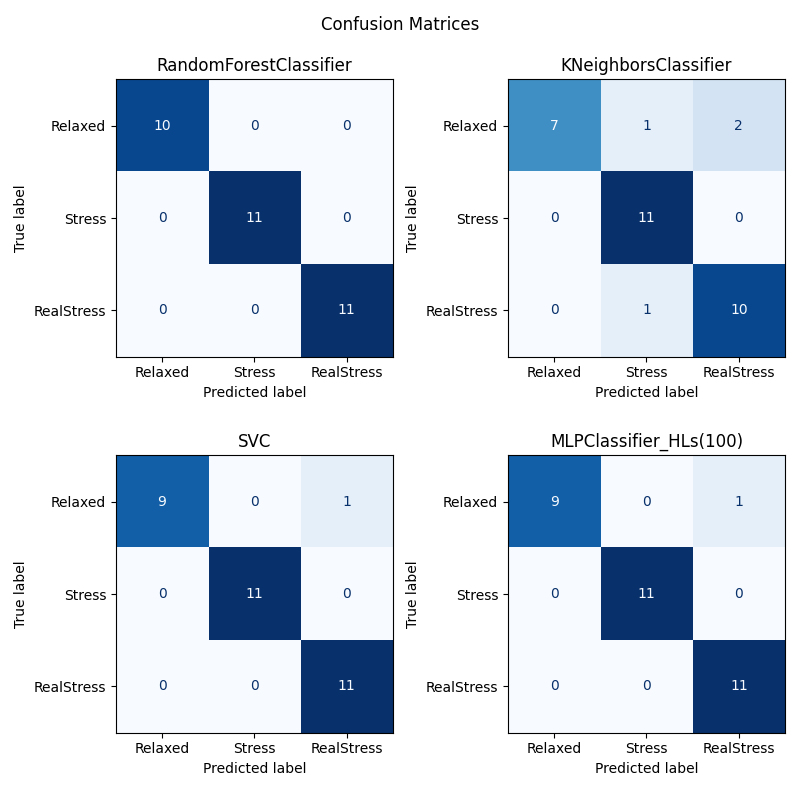

Model RandomForestClassifier saved to ../../experiment-data/results/InterTasks/20251020-203022_ternary_RandomForestClassifier_RFEf.joblib
Model KNeighborsClassifier saved to ../../experiment-data/results/InterTasks/20251020-203022_ternary_KNeighborsClassifier_RFEf.joblib
Model SVC saved to ../../experiment-data/results/InterTasks/20251020-203022_ternary_SVC_RFEf.joblib
Model MLPClassifier_HLs(100) saved to ../../experiment-data/results/InterTasks/20251020-203022_ternary_MLPClassifier_HLs(100)_RFEf.joblib
Standard Deviations 10 holdouts:


,f1-score,accuracy,time
classifier,,,
KNeighborsClassifier,0.052806,0.048084,0.483504
MLPClassifier_HLs(100),0.039786,0.039408,0.606279
RandomForestClassifier,0.053368,0.053412,0.707841
SVC,0.033206,0.033586,0.604597


In [12]:
# 10 random splits holdout
if validations["holdout"]:
    res, conf, models, probs_dict = make_nclassif_random_splits(
        x_in,
        y_in,
        n_splits=params["n_splits"],
        feature_selector=params["feature_selector"],
        list_classifiers=list_classif,
        random_seed=params["state_int"],
        test_size=params["test_size"],
        verbose=params["verbose"],
        useStratification=True,
    )
    output(res, conf, params)
    if params["save_models"]:
        save_models(models, params)

    print(f"Standard Deviations {params['n_splits']} holdouts:")
    display(res.groupby(["classifier"]).std()[["f1-score", "accuracy", "time"]])


Fold 1/5
Fold 2/5
Fold 3/5


/Users/sergio-de/Documents/Research/PhDCourse/UXFrustrationRecognition/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3026: RuntimeWarning: overflow encountered in dot
  return dot(A, dot(B, C), out=out)


Fold 4/5
Fold 5/5
Saving results to ../../experiment-data/results/InterTasks/20251020-203246_ternary_RFEf.21.csv, ../../experiment-data/results/InterTasks/20251020-203246_ternary_RFEf.21.avg.csv


,f1-score,accuracy,time
classifier,,,
KNeighborsClassifier,0.871339,0.867138,6.267943
MLPClassifier_HLs(100),0.889944,0.889293,6.343294
RandomForestClassifier,0.908355,0.907475,6.252816
SVC,0.942572,0.939596,5.423417


Saving confusion matrix to ../../experiment-data/results/InterTasks/20251020-203246_ternary_RFEf.21.CM.png


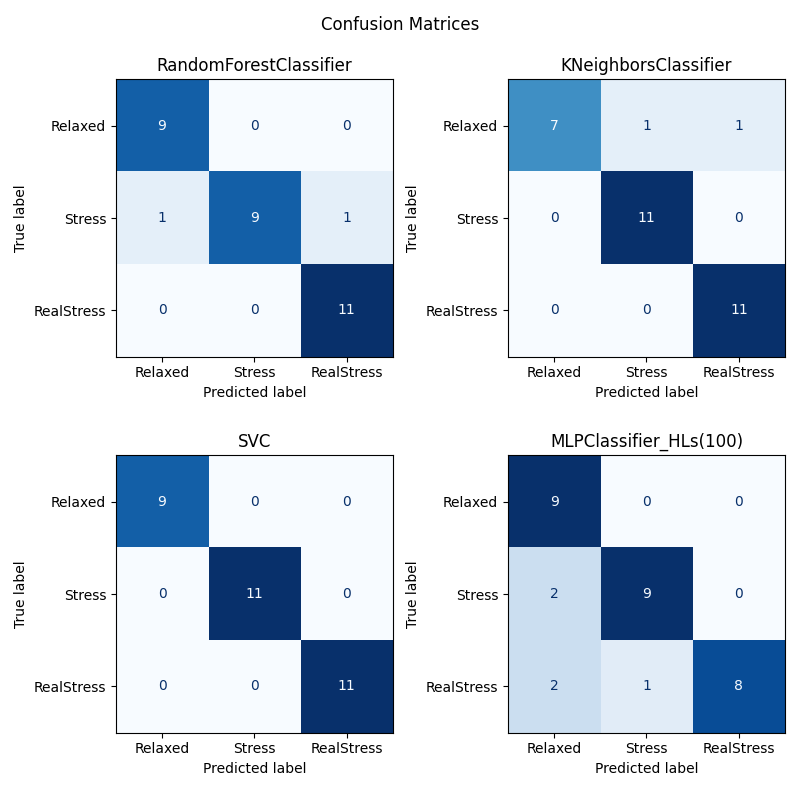

Model RandomForestClassifier saved to ../../experiment-data/results/InterTasks/20251020-203246_ternary_RandomForestClassifier_RFEf.joblib
Model KNeighborsClassifier saved to ../../experiment-data/results/InterTasks/20251020-203246_ternary_KNeighborsClassifier_RFEf.joblib
Model SVC saved to ../../experiment-data/results/InterTasks/20251020-203246_ternary_SVC_RFEf.joblib
Model MLPClassifier_HLs(100) saved to ../../experiment-data/results/InterTasks/20251020-203246_ternary_MLPClassifier_HLs(100)_RFEf.joblib
Standard Deviations 5-folds cross-validation:


,f1-score,accuracy,time
classifier,,,
KNeighborsClassifier,0.058029,0.056531,0.984355
MLPClassifier_HLs(100),0.074990,0.074808,0.844811
RandomForestClassifier,0.063702,0.066212,1.075310
SVC,0.041475,0.042697,0.690044


In [13]:
# 5-fold cross-validation
if validations["kfold"]:
    res, conf, models, probs_dict = make_nclassif_kfold(
        x_in,
        y_in,
        feature_selector=params["feature_selector"],
        list_classifiers=list_classif,
        random_seed=params["state_int"],
        verbose=params["verbose"],
        stratified=True,
    )
    output(res, conf, params)
    if params["save_models"]:
        save_models(models, params)

    print("Standard Deviations 5-folds cross-validation:")
    display(res.groupby(["classifier"]).std()[["f1-score", "accuracy", "time"]])



============ ternary ============


Trained on CALC


,counts,percentage
labels,,
Relaxed,55,35.031847
Stress,55,35.031847
RealStress,47,29.936306



Tested on VIDEO


/Users/sergio-de/Documents/Research/PhDCourse/UXFrustrationRecognition/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/sergio-de/Documents/Research/PhDCourse/UXFrustrationRecognition/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/sergio-de/Documents/Research/PhDCourse/UXFrustrationRecognition/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples

,counts,percentage
labels,,
Relaxed,43,68.253968
Stress,13,20.634921
RealStress,7,11.111111


,bal-accuracy,weighted-f1,macro-avg-prec,macro-avg-rec,macro-avg-f1,stress-prec,stress-rec,stress-f1
classifier,,,,,,,,
RandomForestClassifier,0.317829,0.538156,0.224044,0.317829,0.262821,0.000000,0.000000,0.000000
KNeighborsClassifier,0.366556,0.537112,0.335470,0.366556,0.348178,0.333333,0.285714,0.307692
SVC,0.325581,0.546032,0.225806,0.325581,0.266667,0.000000,0.000000,0.000000
MLPClassifier_HLs(100),0.320215,0.543007,0.305556,0.320215,0.292549,0.000000,0.000000,0.000000


Saving results to ../../experiment-data/results/InterTasks/20251020-203247_ternary_calc_RFEf.21.csv
Saving confusion matrix to ../../experiment-data/results/InterTasks/20251020-203247_ternary_calc_RFEf.21.CM.png


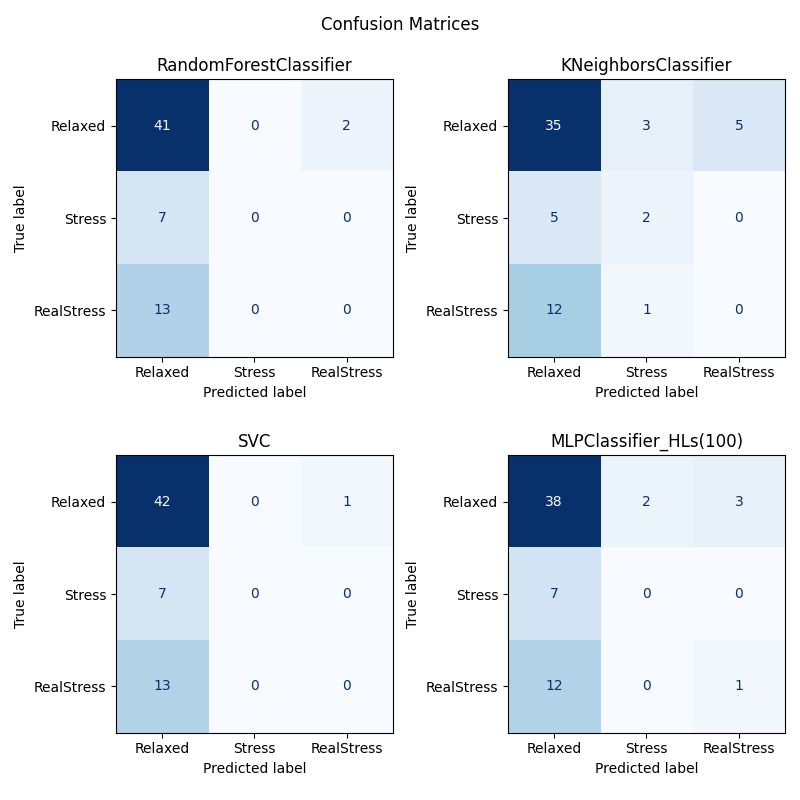

In [14]:
print(f"\n\n============ {params['classification']} ============\n\n")
print(f"Trained on {params['training_tasks'].upper()}")
show_label_stats(params["classes"], y_in)

log_type = f"{params['classification']}_{params['training_tasks']}"
df_res = pd.DataFrame(
    {
        "classifier": [],
        "bal-accuracy": [],
        "weighted-f1": [],
        "macro-avg-prec": [],
        "macro-avg-rec": [],
        "macro-avg-f1": [],
        "stress-prec": [],
        "stress-rec": [],
        "stress-f1": [],
    },
)
conf_matrices: dict[str, np.ndarray] = {}

for model_name, model in models.items():
    y_pred = model.predict(testset_x)
    cm = confusion_matrix(testset_ter_y, y_pred)
    report = classification_report(testset_ter_y, y_pred, target_names=params["classes"], output_dict=True)
    conf_matrices[model_name] = cm

    s_report = report["Stress"]
    m_report = report["macro avg"]
    new_row = {
        "classifier": model_name,
        "bal-accuracy": balanced_accuracy_score(testset_ter_y, y_pred),
        "weighted-f1": f1_score(testset_ter_y, y_pred, average="weighted"),
        "macro-avg-prec": m_report["precision"],
        "macro-avg-rec": m_report["recall"],
        "macro-avg-f1": m_report["f1-score"],
        "stress-prec": s_report["precision"],
        "stress-rec": s_report["recall"],
        "stress-f1": s_report["f1-score"],
    }
    df_res.loc[len(df_res)] = new_row

print(f"\nTested on {params['testing_tasks'].upper()}")
show_label_stats(params["classes"], testset_ter_y)

df_res.set_index("classifier", inplace=True)
show_results(log_type, df_res, params, save=params["save_results"])
if params["show_confusion_matrices"]:
    show_confusion_matrices(log_type, conf_matrices, params, save=params["save_confusion_matrices"])


### Quaternary Classification

In [29]:
params["classification"] = "quaternary"
params["classes"] = QAD_LABELS
show_label_stats(params["classes"], trainset_qad_y)

if params["data_augmentation"]:
    ada = ADASYN(random_state=params["state_int"], sampling_strategy="not minority")
    x_in, y_in = ada.fit_resample(trainset_x, trainset_qad_y)
    print("Resampled dataset")
    show_label_stats(params["classes"], y_in)
else:
    x_in = trainset_x.copy()
    y_in = trainset_qad_y.copy()

,counts,percentage
labels,,
Relaxed,38,60.317460
Stress,13,20.634921
RealStress,9,14.285714
Amused,3,4.761905


Resampled dataset


,counts,percentage
labels,,
Relaxed,41,34.453782
Stress,38,31.932773
RealStress,37,31.092437
Amused,3,2.521008


Split  1/10
Split  2/10
Split  3/10
Split  4/10
Split  5/10
Split  6/10
Split  7/10
Split  8/10
Split  9/10
Split 10/10
Saving results to ../../experiment-data/results/InterTasks/20251020-212135_quaternary_RFEf.21.csv, ../../experiment-data/results/InterTasks/20251020-212135_quaternary_RFEf.21.avg.csv


,f1-score,accuracy,time
classifier,,,
KNeighborsClassifier,0.757426,0.606250,5.361505
MLPClassifier_HLs(100),0.794101,0.641518,5.297426
RandomForestClassifier,0.786787,0.633929,5.600536
SVC,0.842274,0.675893,5.435196


Saving confusion matrix to ../../experiment-data/results/InterTasks/20251020-212135_quaternary_RFEf.21.CM.png


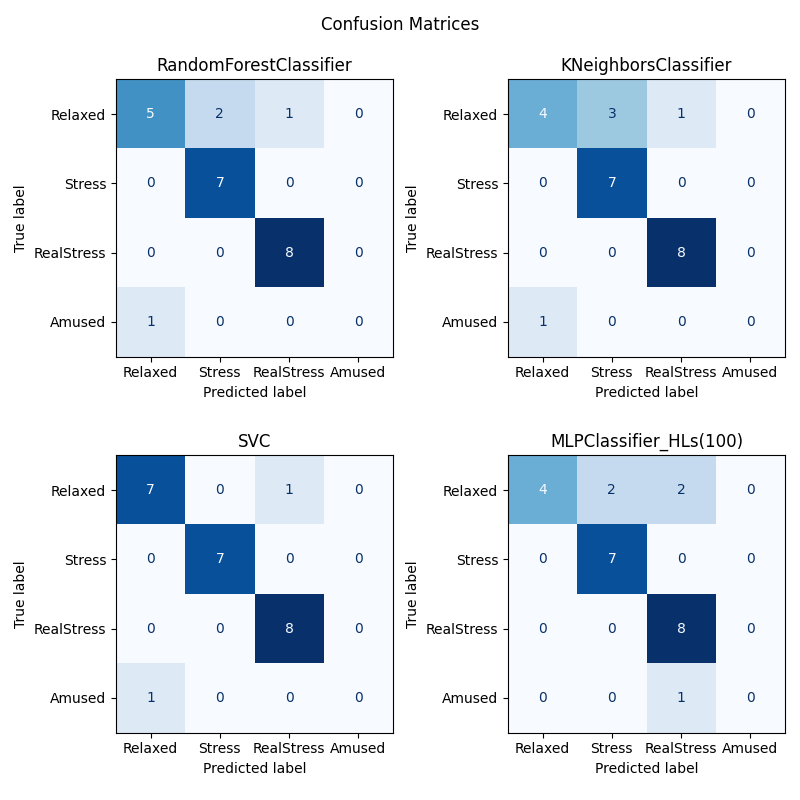

Model RandomForestClassifier saved to ../../experiment-data/results/InterTasks/20251020-212136_quaternary_RandomForestClassifier_RFEf.joblib
Model KNeighborsClassifier saved to ../../experiment-data/results/InterTasks/20251020-212136_quaternary_KNeighborsClassifier_RFEf.joblib
Model SVC saved to ../../experiment-data/results/InterTasks/20251020-212136_quaternary_SVC_RFEf.joblib
Model MLPClassifier_HLs(100) saved to ../../experiment-data/results/InterTasks/20251020-212136_quaternary_MLPClassifier_HLs(100)_RFEf.joblib
Standard Deviations 10 holdouts:


,f1-score,accuracy,time
classifier,,,
KNeighborsClassifier,0.093057,0.079130,0.661773
MLPClassifier_HLs(100),0.062165,0.040429,0.565495
RandomForestClassifier,0.058424,0.043487,0.588715
SVC,0.063036,0.048595,0.468469


In [34]:
# 10 random splits holdout
if validations["holdout"]:
    res, conf, models, probs_dict = make_nclassif_random_splits(
        x_in,
        y_in,
        n_splits=params["n_splits"],
        feature_selector=params["feature_selector"],
        list_classifiers=list_classif,
        random_seed=params["state_int"],
        test_size=params["test_size"],
        verbose=params["verbose"],
        useStratification=True,
    )
    output(res, conf, params)
    if params["save_models"]:
        save_models(models, params)

    print(f"Standard Deviations {params['n_splits']} holdouts:")
    display(res.groupby(["classifier"]).std()[["f1-score", "accuracy", "time"]])

/Users/sergio-de/Documents/Research/PhDCourse/UXFrustrationRecognition/lib/python3.13/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5


/Users/sergio-de/Documents/Research/PhDCourse/UXFrustrationRecognition/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Saving results to ../../experiment-data/results/InterTasks/20251020-210456_quaternary_RFEf.21.csv, ../../experiment-data/results/InterTasks/20251020-210456_quaternary_RFEf.21.avg.csv


,f1-score,accuracy,time
classifier,,,
KNeighborsClassifier,0.734546,0.666964,4.915552
MLPClassifier_HLs(100),0.838427,0.743452,5.081246
RandomForestClassifier,0.845371,0.744643,5.136591
SVC,0.868450,0.765179,4.736334


ValueError: The number of FixedLocator locations (3), usually from a call to set_ticks, does not match the number of labels (4).

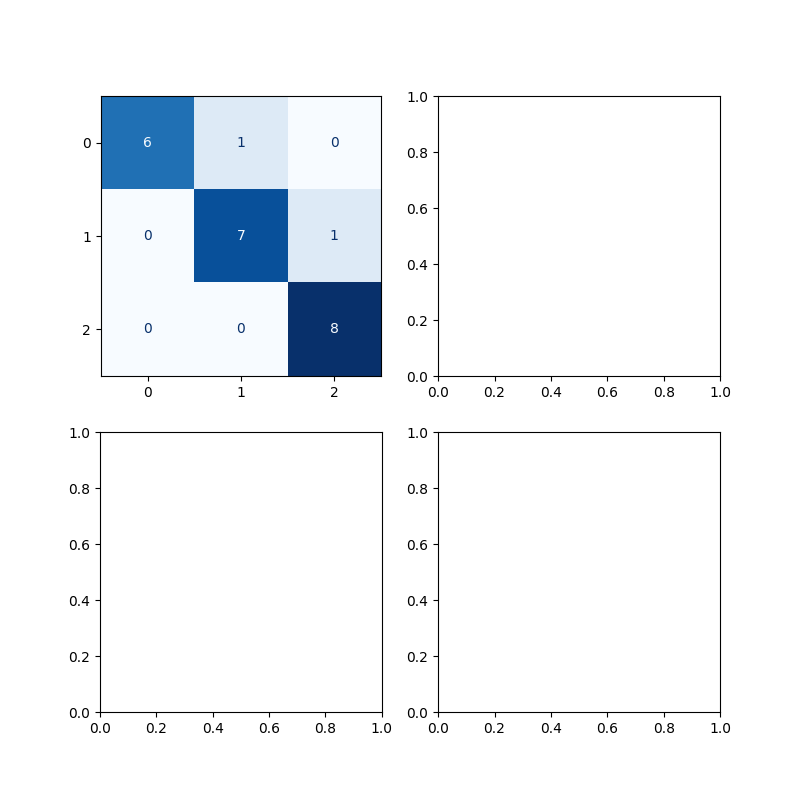

In [ ]:
# 5-fold cross-validation
if validations["kfold"]:
    res, conf, models, probs_dict = make_nclassif_kfold(
        x_in,
        y_in,
        feature_selector=params["feature_selector"],
        list_classifiers=list_classif,
        random_seed=params["state_int"],
        verbose=params["verbose"],
        stratified=True,
    )
    output(res, conf, params)
    if params["save_models"]:
        save_models(models, params)

    print("Standard Deviations 5-folds cross-validation:")
    display(res.groupby(["classifier"]).std()[["f1-score", "accuracy", "time"]])



============ quaternary ============


Trained on CALC


,counts,percentage
labels,,
Relaxed,41,34.453782
Stress,38,31.932773
RealStress,37,31.092437
Amused,3,2.521008



Tested on VIDEO


/Users/sergio-de/Documents/Research/PhDCourse/UXFrustrationRecognition/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/sergio-de/Documents/Research/PhDCourse/UXFrustrationRecognition/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/sergio-de/Documents/Research/PhDCourse/UXFrustrationRecognition/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples

,counts,percentage
labels,,
Relaxed,35,55.555556
Stress,12,19.047619
RealStress,10,15.873016
Amused,6,9.523810


,bal-accuracy,weighted-f1,macro-avg-prec,macro-avg-rec,macro-avg-f1,stress-prec,stress-rec,stress-f1
classifier,,,,,,,,
RandomForestClassifier,0.207143,0.354090,0.129464,0.207143,0.159341,0.000000,0.0,0.000000
KNeighborsClassifier,0.250000,0.348269,0.190747,0.250000,0.216245,0.285714,0.4,0.333333
SVC,0.228571,0.374269,0.133333,0.228571,0.168421,0.000000,0.0,0.000000
MLPClassifier_HLs(100),0.185714,0.328283,0.122642,0.185714,0.147727,0.000000,0.0,0.000000


Saving results to ../../experiment-data/results/InterTasks/20251020-212202_quaternary_calc_RFEf.21.csv
Saving confusion matrix to ../../experiment-data/results/InterTasks/20251020-212202_quaternary_calc_RFEf.21.CM.png


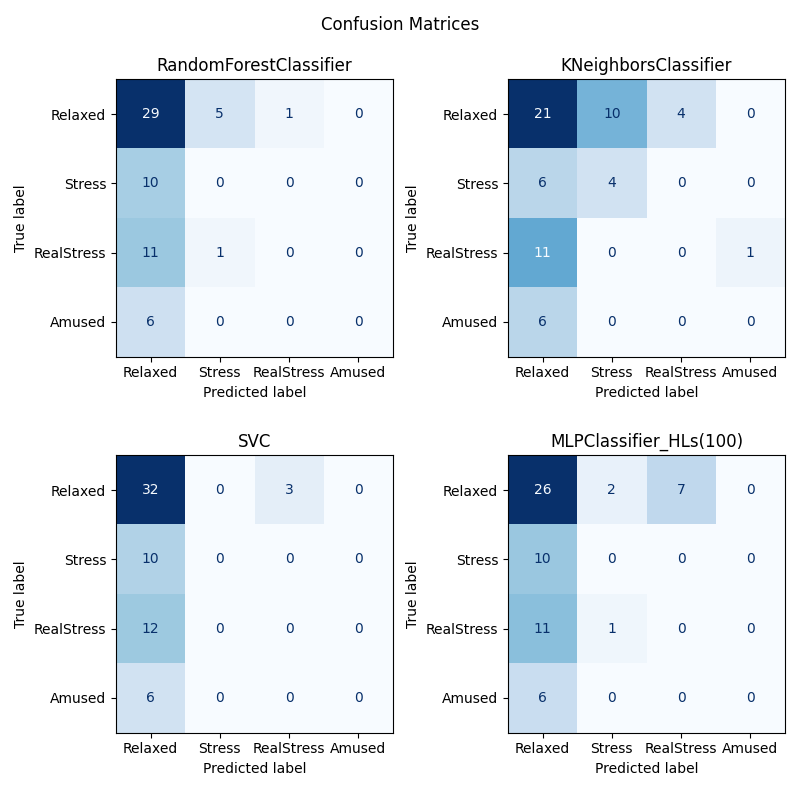

In [35]:
print(f"\n\n============ {params['classification']} ============\n\n")
print(f"Trained on {params['training_tasks'].upper()}")
show_label_stats(params["classes"], y_in)

log_type = f"{params['classification']}_{params['training_tasks']}"
df_res = pd.DataFrame(
    {
        "classifier": [],
        "bal-accuracy": [],
        "weighted-f1": [],
        "macro-avg-prec": [],
        "macro-avg-rec": [],
        "macro-avg-f1": [],
        "stress-prec": [],
        "stress-rec": [],
        "stress-f1": [],
    },
)
conf_matrices: dict[str, np.ndarray] = {}

for model_name, model in models.items():
    y_pred = model.predict(testset_x)
    cm = confusion_matrix(testset_qad_y, y_pred)
    report = classification_report(testset_qad_y, y_pred, target_names=params["classes"], output_dict=True)
    conf_matrices[model_name] = cm

    s_report = report["Stress"]
    m_report = report["macro avg"]
    new_row = {
        "classifier": model_name,
        "bal-accuracy": balanced_accuracy_score(testset_qad_y, y_pred),
        "weighted-f1": f1_score(testset_qad_y, y_pred, average="weighted"),
        "macro-avg-prec": m_report["precision"],
        "macro-avg-rec": m_report["recall"],
        "macro-avg-f1": m_report["f1-score"],
        "stress-prec": s_report["precision"],
        "stress-rec": s_report["recall"],
        "stress-f1": s_report["f1-score"],
    }
    df_res.loc[len(df_res)] = new_row

print(f"\nTested on {params['testing_tasks'].upper()}")
show_label_stats(params["classes"], testset_qad_y)

df_res.set_index("classifier", inplace=True)
show_results(log_type, df_res, params, save=params["save_results"])
if params["show_confusion_matrices"]:
    show_confusion_matrices(log_type, conf_matrices, params, save=params["save_confusion_matrices"])
